# Bank Marketing Dataset — Personal Loan Acceptance Prediction

**Objective:** Predict which customers are likely to accept a personal loan offer from the bank.

**Dataset:** Bank Marketing Dataset — UCI Machine Learning Repository

**Project Steps:**
1. Import Libraries
2. Load Dataset
3. Data Exploration
4. Handle Duplicates and Missing Values
5. Color Theme Setup
6. Visualization
7. Model Building and Evaluation

---
## Step 1 — Import Libraries

We import all libraries needed for data loading, analysis, visualization, and machine learning.

In [2]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
from matplotlib.patches import Patch

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

import warnings
warnings.filterwarnings('ignore')

print('All libraries imported successfully!')

All libraries imported successfully!


---
## Step 2 — Load Dataset

We load the Bank Marketing CSV file using pandas. This dataset contains records of customers contacted during a telephone marketing campaign run by a Portuguese bank. The bank wanted customers to subscribe to a term deposit.

In [3]:
bank_marketing_df = pd.read_csv("bank-direct-marketing-campaigns.csv") 
print('Data load successfull !')

# Rename target column y to Loan_Accepted for better readability
bank_marketing_df = bank_marketing_df.rename(columns={'y': 'Loan_Accepted'})

print('Dataset loaded successfully!')
print(f'Rows   : {bank_marketing_df.shape[0]}')
print(f'Columns: {bank_marketing_df.shape[1]}')

Data load successfull !
Dataset loaded successfully!
Rows   : 41188
Columns: 20


---
## Step 3 — Data Exploration

Before building any model we explore the dataset structure to understand column names, data types, and basic statistics.

In [4]:
# First 3 rows of the dataset
print('First 3 rows:')
bank_marketing_df.head(3)

First 3 rows:


,age,job,marital,education,default,housing,loan,contact,month,day_of_week,campaign,pdays,previous,poutcome,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed,Loan_Accepted
0,56,housemaid,married,basic.4y,no,no,no,telephone,may,mon,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
1,57,services,married,high.school,unknown,no,no,telephone,may,mon,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
2,37,services,married,high.school,no,yes,no,telephone,may,mon,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no


In [5]:
# All column names
print('Column names:')
print(bank_marketing_df.columns.tolist())

Column names:
['age', 'job', 'marital', 'education', 'default', 'housing', 'loan', 'contact', 'month', 'day_of_week', 'campaign', 'pdays', 'previous', 'poutcome', 'emp.var.rate', 'cons.price.idx', 'cons.conf.idx', 'euribor3m', 'nr.employed', 'Loan_Accepted']


In [6]:
# Data types and non-null counts for each column
print('Dataset Info:')
bank_marketing_df.info()

Dataset Info:
<class 'pandas.DataFrame'>
RangeIndex: 41188 entries, 0 to 41187
Data columns (total 20 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   age             41188 non-null  int64  
 1   job             41188 non-null  str    
 2   marital         41188 non-null  str    
 3   education       41188 non-null  str    
 4   default         41188 non-null  str    
 5   housing         41188 non-null  str    
 6   loan            41188 non-null  str    
 7   contact         41188 non-null  str    
 8   month           41188 non-null  str    
 9   day_of_week     41188 non-null  str    
 10  campaign        41188 non-null  int64  
 11  pdays           41188 non-null  int64  
 12  previous        41188 non-null  int64  
 13  poutcome        41188 non-null  str    
 14  emp.var.rate    41188 non-null  float64
 15  cons.price.idx  41188 non-null  float64
 16  cons.conf.idx   41188 non-null  float64
 17  euribor3m       41188 non-nu

In [7]:
# Statistical summary — mean, min, max for numeric columns
print('Statistical Summary:')
bank_marketing_df.describe()

Statistical Summary:


,age,campaign,pdays,previous,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed
count,41188.00000,41188.000000,41188.000000,41188.000000,41188.000000,41188.000000,41188.000000,41188.000000,41188.000000
mean,40.02406,2.567593,962.475454,0.172963,0.081886,93.575664,-40.502600,3.621291,5167.035911
std,10.42125,2.770014,186.910907,0.494901,1.570960,0.578840,4.628198,1.734447,72.251528
min,17.00000,1.000000,0.000000,0.000000,-3.400000,92.201000,-50.800000,0.634000,4963.600000
25%,32.00000,1.000000,999.000000,0.000000,-1.800000,93.075000,-42.700000,1.344000,5099.100000
50%,38.00000,2.000000,999.000000,0.000000,1.100000,93.749000,-41.800000,4.857000,5191.000000
75%,47.00000,3.000000,999.000000,0.000000,1.400000,93.994000,-36.400000,4.961000,5228.100000
max,98.00000,56.000000,999.000000,7.000000,1.400000,94.767000,-26.900000,5.045000,5228.100000


---
## Step 4 — Handle Duplicates and Missing Values

Duplicate rows can cause a model to overfit by learning the same pattern multiple times. Missing values must also be checked before training because most models cannot handle them directly.

In [8]:
# Check how many duplicate rows exist
print(f'Duplicate rows before dropping: {bank_marketing_df.duplicated().sum()}')

# Drop duplicate rows and save result back to dataframe
bank_marketing_df = bank_marketing_df.drop_duplicates()

print(f'Duplicate rows after dropping : {bank_marketing_df.duplicated().sum()}')
print(f'New shape: {bank_marketing_df.shape[0]} rows, {bank_marketing_df.shape[1]} columns')

Duplicate rows before dropping: 1784
Duplicate rows after dropping : 0
New shape: 39404 rows, 20 columns


In [9]:
# Check missing values in each column
missing = bank_marketing_df.isnull().sum()
if missing.sum() == 0:
    print('No missing values found in any column.')
else:
    print('Missing values per column:')
    print(missing[missing > 0])

No missing values found in any column.


---
## Step 5 — Color Theme Setup

We define a consistent color palette so all graphs throughout the notebook look professional and visually consistent.

In [10]:
colors = {
    'yes'        : '#1D9E75',
    'no'         : '#D85A30',
    'cellular'   : '#378ADD',
    'telephone'  : '#7F77DD',
    'married'    : '#D4537E',
    'single'     : '#5DCAA5',
    'divorced'   : '#BA7517',
    'university' : '#185FA5',
    'high.school': '#534AB7',
    'basic'      : '#639922',
    'unknown'    : '#888780',
    'highlight'  : '#EF9F27',
    'background' : '#F1EFE8',
    'title'      : '#26215C',
    'subtitle'   : '#534AB7',
}

yes_no_palette        = {'yes': colors['yes'], 'no': colors['no']}
contact_palette       = {'cellular': colors['cellular'], 'telephone': colors['telephone']}
marital_palette       = {'married': colors['married'], 'single': colors['single'], 'divorced': colors['divorced']}
education_palette     = {'university.degree': colors['university'], 'high.school': colors['high.school'], 'basic.9y': colors['basic'], 'unknown': colors['unknown']}
housing_palette       = {'yes': colors['yes'], 'no': colors['no'], 'unknown': colors['unknown']}
personal_loan_palette = {'yes': colors['yes'], 'no': colors['no'], 'unknown': colors['unknown']}
default_palette       = {'yes': colors['yes'], 'no': colors['no'], 'unknown': colors['unknown']}
poutcome_palette      = {'success': colors['yes'], 'failure': colors['no'], 'nonexistent': colors['unknown']}

print('Color theme ready!')

Color theme ready!


---
## Step 6 — Visualization

### Chapter 1 — Customer Information

We explore the personal details of customers — age, education, job type, and marital status — to understand which customer groups are most likely to accept the loan offer.

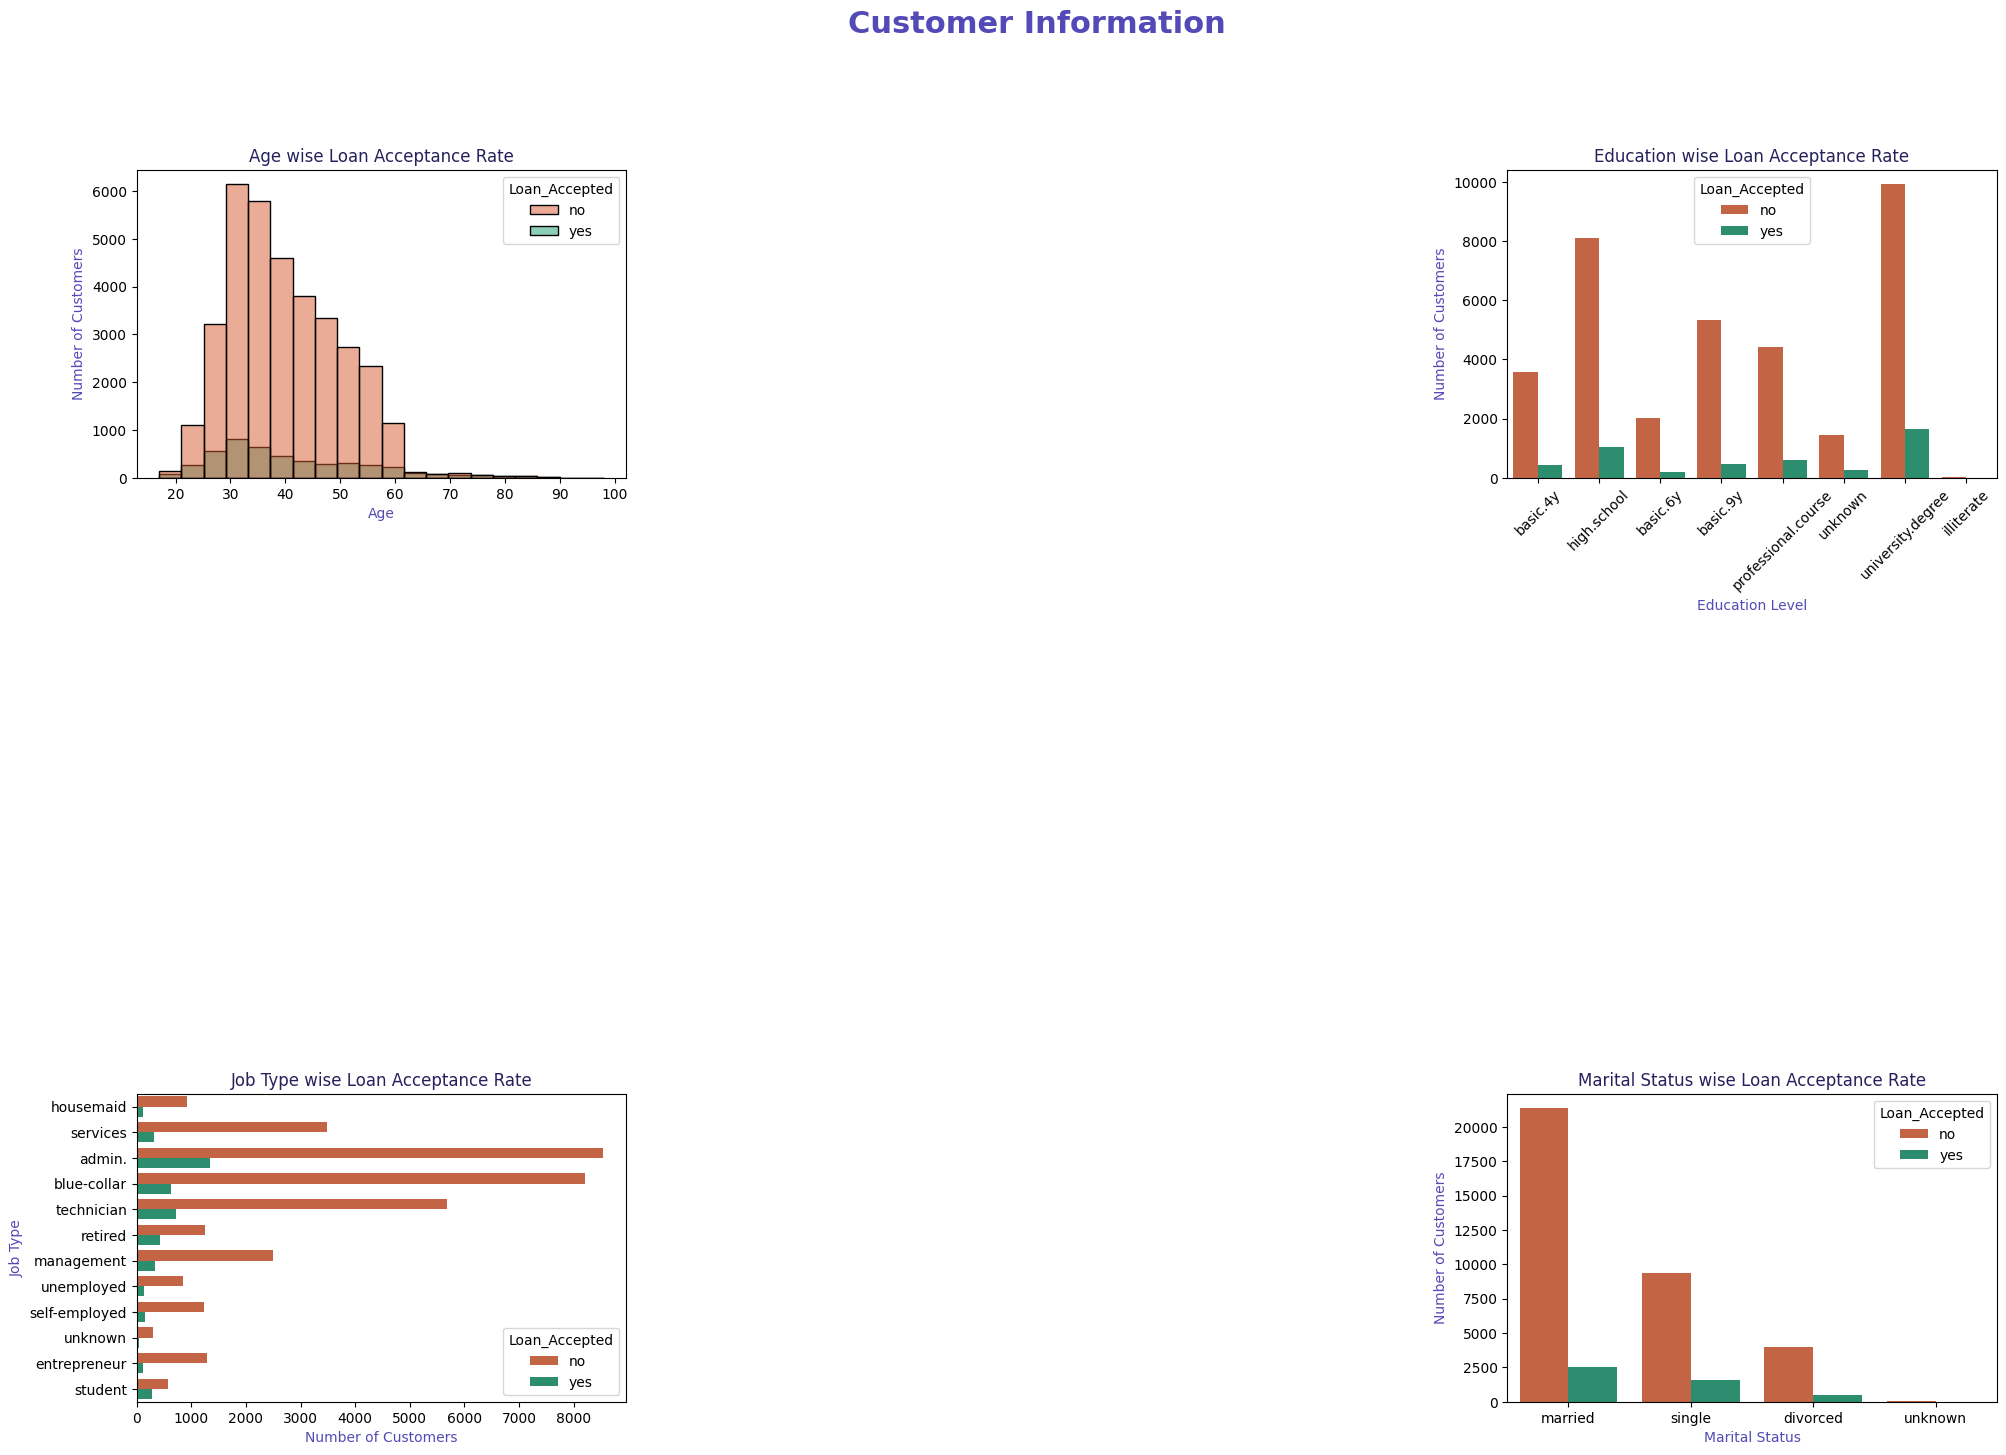

In [11]:
# Customer Information — 4 graphs arranged in a 3x3 grid
# Corner positions used: top-left, top-right, bottom-left, bottom-right
fig, axes = plt.subplots(3, 3, figsize=(24, 16))
fig.suptitle('Customer Information', color=colors['subtitle'], fontsize=22, fontweight='bold')

# Graph 1 — Age wise loan acceptance
# histplot is used because age has too many unique values for a countplot
sns.histplot(x='age', hue='Loan_Accepted', bins=20,
             data=bank_marketing_df, palette=yes_no_palette, ax=axes[0][0])
axes[0][0].set_title('Age wise Loan Acceptance Rate', color=colors['title'])
axes[0][0].set_xlabel('Age', color=colors['subtitle'])
axes[0][0].set_ylabel('Number of Customers', color=colors['subtitle'])

# Graph 2 — Education wise loan acceptance
sns.countplot(x='education', hue='Loan_Accepted', data=bank_marketing_df,
              palette=yes_no_palette, ax=axes[0][2])
axes[0][2].set_title('Education wise Loan Acceptance Rate', color=colors['title'])
axes[0][2].set_xlabel('Education Level', color=colors['subtitle'])
axes[0][2].set_ylabel('Number of Customers', color=colors['subtitle'])
axes[0][2].tick_params(axis='x', rotation=45)

# Graph 3 — Job type wise loan acceptance (horizontal bars for better label readability)
sns.countplot(y='job', hue='Loan_Accepted', data=bank_marketing_df,
              palette=yes_no_palette, ax=axes[2][0])
axes[2][0].set_title('Job Type wise Loan Acceptance Rate', color=colors['title'])
axes[2][0].set_xlabel('Number of Customers', color=colors['subtitle'])
axes[2][0].set_ylabel('Job Type', color=colors['subtitle'])

# Graph 4 — Marital status wise loan acceptance
sns.countplot(x='marital', hue='Loan_Accepted', data=bank_marketing_df,
              palette=yes_no_palette, ax=axes[2][2])
axes[2][2].set_title('Marital Status wise Loan Acceptance Rate', color=colors['title'])
axes[2][2].set_xlabel('Marital Status', color=colors['subtitle'])
axes[2][2].set_ylabel('Number of Customers', color=colors['subtitle'])

# Hide all empty subplot cells
for i in range(3):
    for j in range(3):
        if (i, j) not in [(0, 0), (0, 2), (2, 0), (2, 2)]:
            axes[i][j].set_visible(False)

plt.subplots_adjust(hspace=0.5, wspace=0.4)
plt.show()

---
### Chapter 2 — Loan and Contact Analysis

We analyze the distribution of housing loans, personal loans, and default history. We also check which contact method produced a better acceptance rate, and how many calls were typically needed per customer.

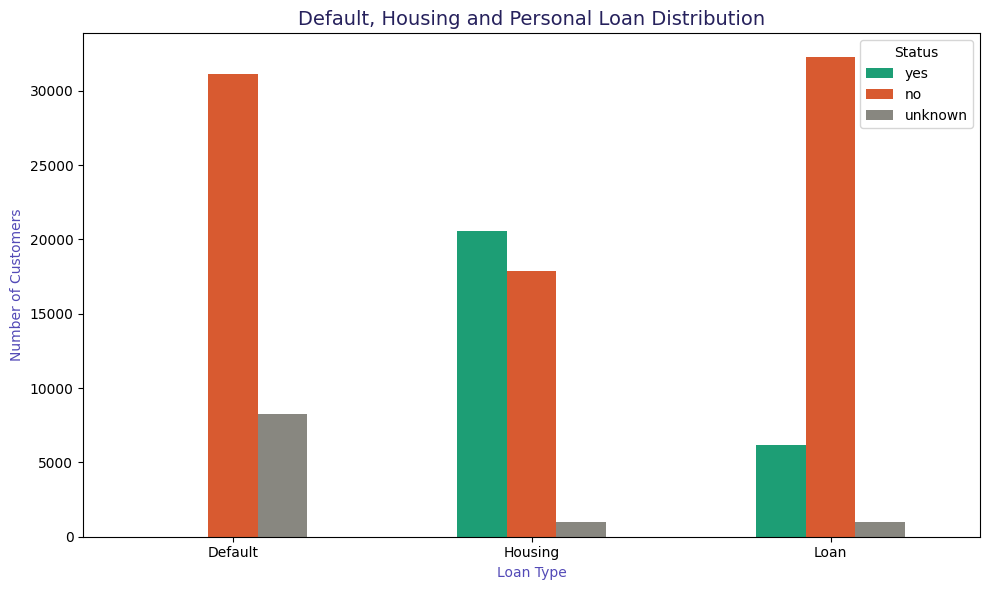

In [12]:
# Graph — Default, Housing and Personal Loan Distribution
# reindex ensures yes, no, unknown appear in the same order for all three columns
default_counts = bank_marketing_df['default'].value_counts().reindex(['yes', 'no', 'unknown'], fill_value=0)
housing_counts = bank_marketing_df['housing'].value_counts().reindex(['yes', 'no', 'unknown'], fill_value=0)
loan_counts    = bank_marketing_df['loan'].value_counts().reindex(['yes', 'no', 'unknown'], fill_value=0)

combined = pd.DataFrame({
    'Default' : default_counts,
    'Housing' : housing_counts,
    'Loan'    : loan_counts
}).T

plt.figure(figsize=(10, 6))
combined.plot(kind='bar',
              color=[colors['yes'], colors['no'], colors['unknown']],
              ax=plt.gca())

plt.title('Default, Housing and Personal Loan Distribution', color=colors['title'], fontsize=14)
plt.xlabel('Loan Type', color=colors['subtitle'])
plt.ylabel('Number of Customers', color=colors['subtitle'])
plt.xticks(rotation=0)
plt.legend(title='Status')
plt.tight_layout()
plt.show()

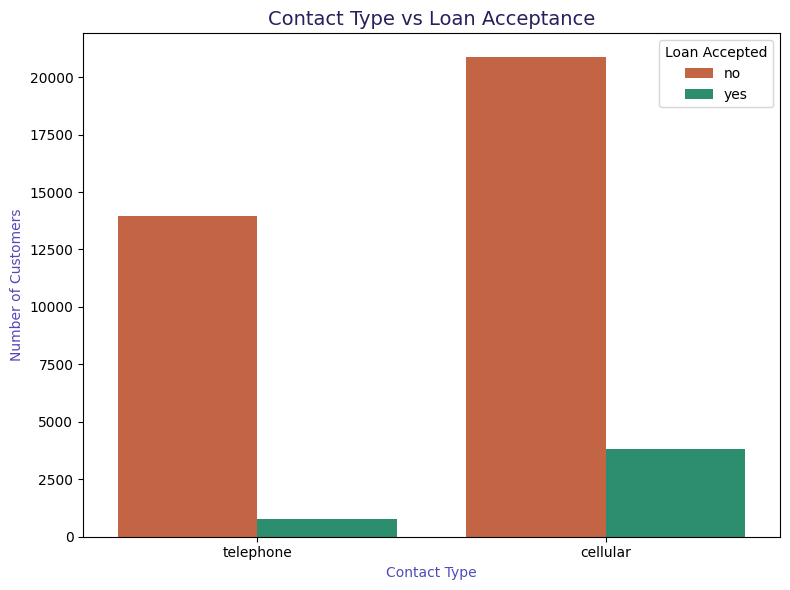

In [13]:
# Graph — Contact Type vs Loan Acceptance
# Did customers contacted via mobile accept more than those on landline?
plt.figure(figsize=(8, 6))
sns.countplot(x='contact', hue='Loan_Accepted', data=bank_marketing_df, palette=yes_no_palette)

plt.title('Contact Type vs Loan Acceptance', color=colors['title'], fontsize=14)
plt.xlabel('Contact Type', color=colors['subtitle'])
plt.ylabel('Number of Customers', color=colors['subtitle'])
plt.legend(title='Loan Accepted')
plt.tight_layout()
plt.show()

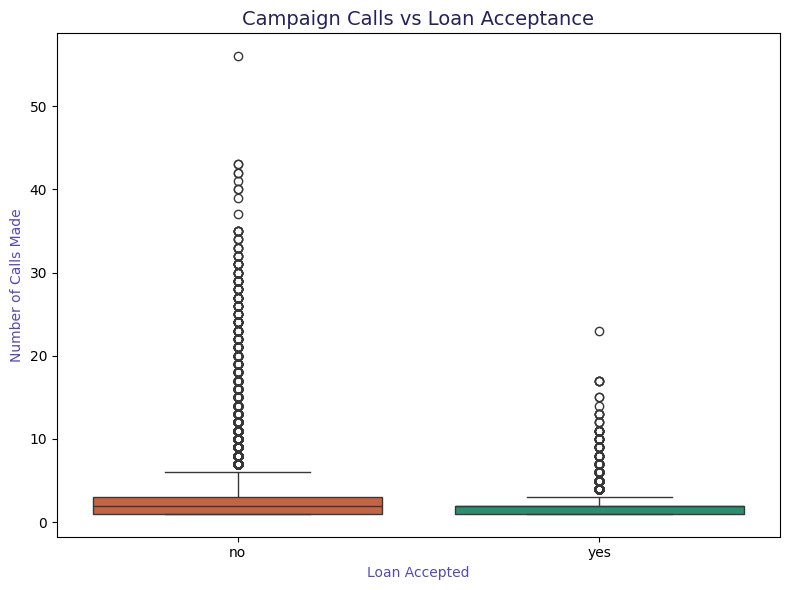

In [14]:
# Graph — Campaign Calls vs Loan Acceptance
# Box plot shows the minimum, maximum, and median calls made per customer
plt.figure(figsize=(8, 6))
sns.boxplot(x='Loan_Accepted', y='campaign', data=bank_marketing_df, palette=yes_no_palette)

plt.title('Campaign Calls vs Loan Acceptance', color=colors['title'], fontsize=14)
plt.xlabel('Loan Accepted', color=colors['subtitle'])
plt.ylabel('Number of Calls Made', color=colors['subtitle'])
plt.tight_layout()
plt.show()

---
### Chapter 3 — Economic Indicators

We check how external economic conditions such as employment rate, consumer price index, and the European interest rate (Euribor) affected whether customers accepted the loan offer.

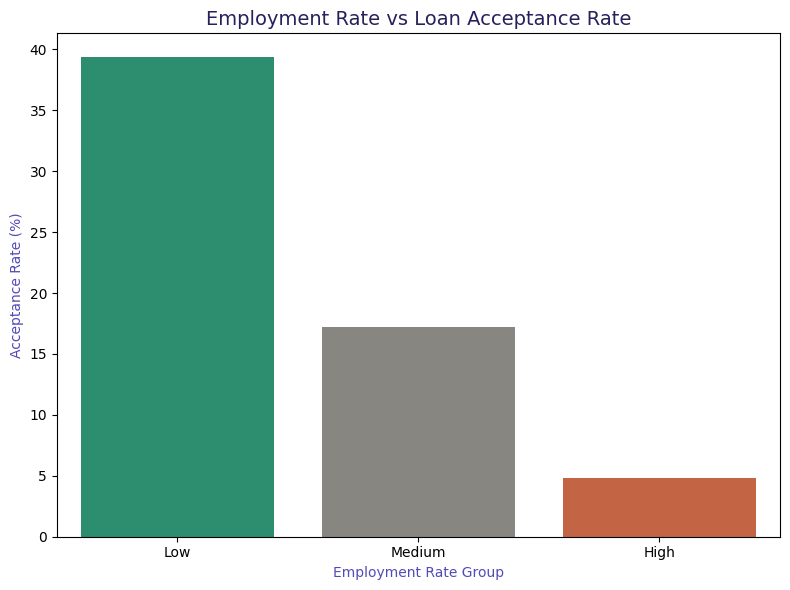

In [15]:
# Graph — Employment Rate vs Loan Acceptance
# emp.var.rate divided into Low, Medium, High groups to see the acceptance trend clearly
bank_marketing_df['emp_rate_group'] = pd.cut(
    bank_marketing_df['emp.var.rate'],
    bins=[-5, -2, 0, 2],
    labels=['Low', 'Medium', 'High']
)

acceptance_rate = bank_marketing_df.groupby('emp_rate_group')['Loan_Accepted'].apply(
    lambda x: (x == 'yes').sum() / len(x) * 100
).reset_index()
acceptance_rate.columns = ['emp_rate_group', 'Acceptance_Rate']

plt.figure(figsize=(8, 6))
sns.barplot(x='emp_rate_group', y='Acceptance_Rate', data=acceptance_rate,
            palette=[colors['yes'], colors['unknown'], colors['no']])

plt.title('Employment Rate vs Loan Acceptance Rate', color=colors['title'], fontsize=14)
plt.xlabel('Employment Rate Group', color=colors['subtitle'])
plt.ylabel('Acceptance Rate (%)', color=colors['subtitle'])
plt.tight_layout()
plt.show()

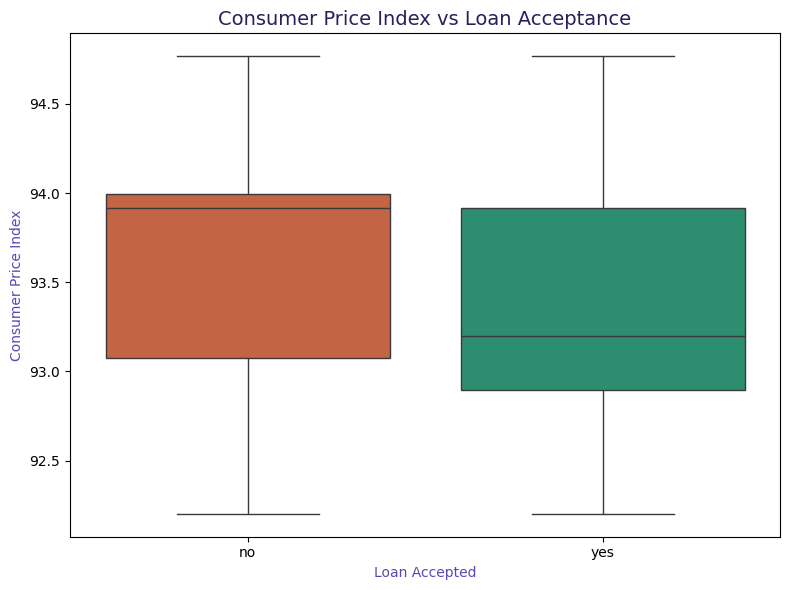

In [16]:
# Graph — Consumer Price Index vs Loan Acceptance
# When inflation is high, are customers still willing to accept the offer?
plt.figure(figsize=(8, 6))
sns.boxplot(x='Loan_Accepted', y='cons.price.idx',
            hue='Loan_Accepted', data=bank_marketing_df, palette=yes_no_palette)

plt.title('Consumer Price Index vs Loan Acceptance', color=colors['title'], fontsize=14)
plt.xlabel('Loan Accepted', color=colors['subtitle'])
plt.ylabel('Consumer Price Index', color=colors['subtitle'])
plt.tight_layout()
plt.show()

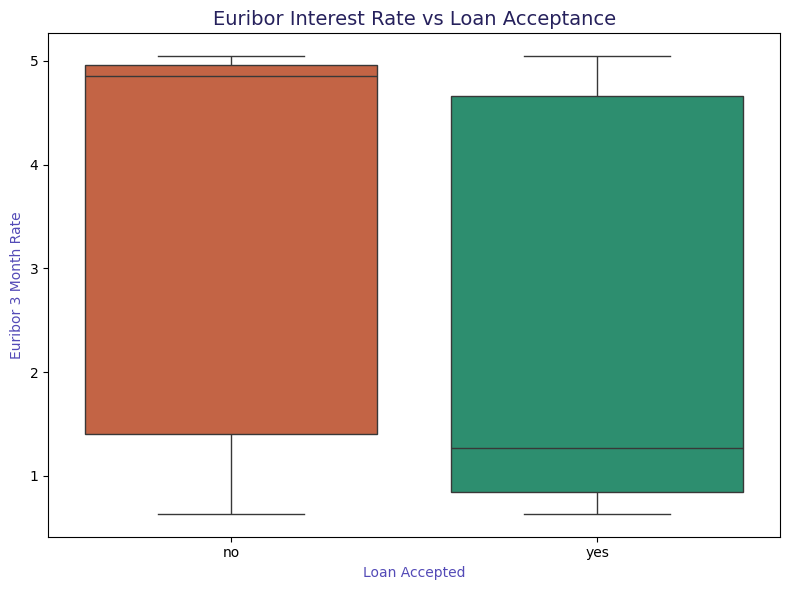

In [17]:
# Graph — Euribor Rate vs Loan Acceptance
# When the European interest rate is high, does it reduce customer interest in loans?
plt.figure(figsize=(8, 6))
sns.boxplot(x='Loan_Accepted', y='euribor3m',
            hue='Loan_Accepted', data=bank_marketing_df, palette=yes_no_palette)

plt.title('Euribor Interest Rate vs Loan Acceptance', color=colors['title'], fontsize=14)
plt.xlabel('Loan Accepted', color=colors['subtitle'])
plt.ylabel('Euribor 3 Month Rate', color=colors['subtitle'])
plt.tight_layout()
plt.show()

---
### Chapter 4 — Additional Analysis

Two important graphs added here:
1. Month wise loan acceptance — which months had the highest acceptance rate.
2. Previous campaign outcome — if a customer accepted before, did they accept again.

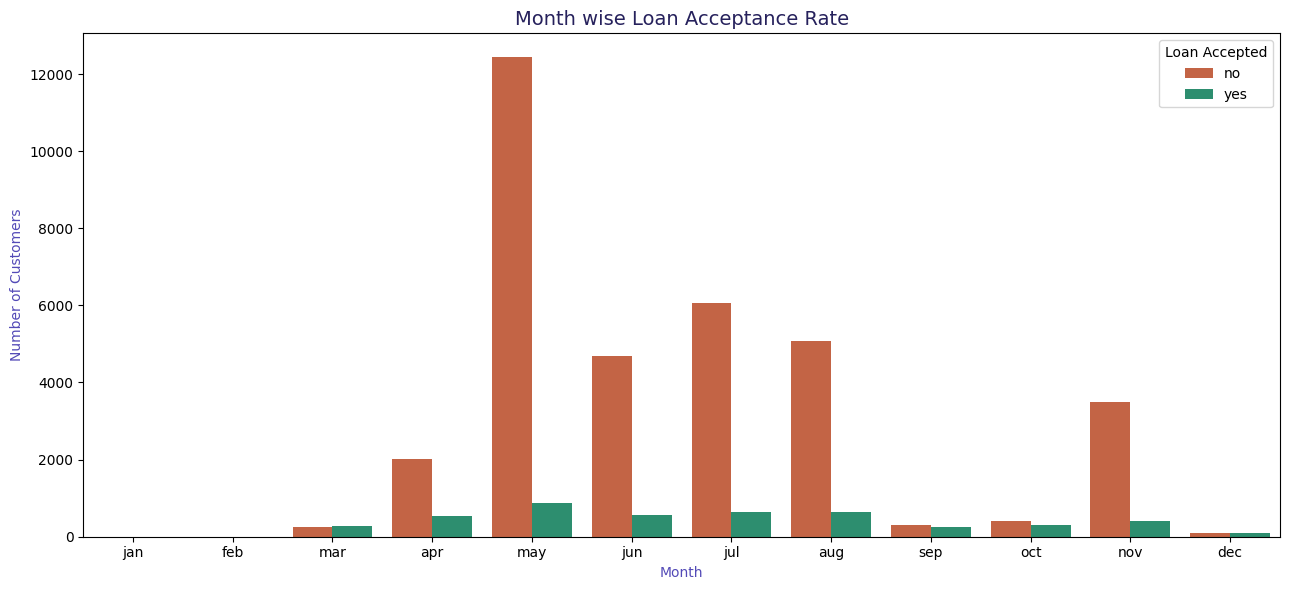

In [18]:
# Graph — Month wise Loan Acceptance Rate
# Months ordered from January to December for a clear timeline view
month_order = ['jan', 'feb', 'mar', 'apr', 'may', 'jun',
               'jul', 'aug', 'sep', 'oct', 'nov', 'dec']

plt.figure(figsize=(13, 6))
sns.countplot(x='month', hue='Loan_Accepted', data=bank_marketing_df,
              order=month_order, palette=yes_no_palette)

plt.title('Month wise Loan Acceptance Rate', color=colors['title'], fontsize=14)
plt.xlabel('Month', color=colors['subtitle'])
plt.ylabel('Number of Customers', color=colors['subtitle'])
plt.legend(title='Loan Accepted')
plt.tight_layout()
plt.show()

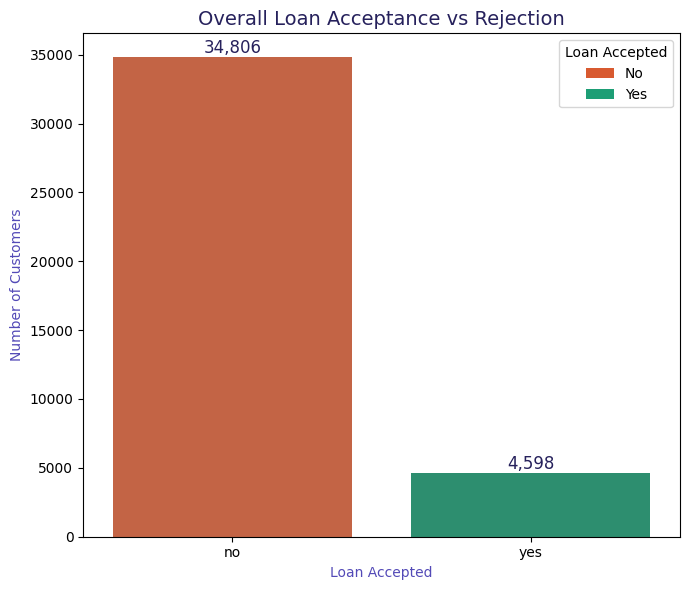

In [20]:
# Graph — Overall Loan Acceptance vs Rejection
# How many customers said yes vs no to the loan offer in total?
plt.figure(figsize=(7, 6))
ax = sns.countplot(x='Loan_Accepted', data=bank_marketing_df, palette=yes_no_palette)

# Add count labels on top of each bar
for p in ax.patches:
    ax.annotate(f'{int(p.get_height()):,}',
                (p.get_x() + p.get_width() / 2., p.get_height()),
                ha='center', va='bottom', fontsize=12, color=colors['title'])

legend_elements = [
    Patch(facecolor=colors['no'],  label='No'),
    Patch(facecolor=colors['yes'], label='Yes')
]
plt.legend(handles=legend_elements, title='Loan Accepted')
plt.title('Overall Loan Acceptance vs Rejection', color=colors['title'], fontsize=14)
plt.xlabel('Loan Accepted', color=colors['subtitle'])
plt.ylabel('Number of Customers', color=colors['subtitle'])
plt.tight_layout()
plt.show()

---
## Step 7 — Model Building

### Data Preprocessing

Machine learning models only understand numeric data. We use Label Encoder to convert all categorical (text) columns into numbers. We also remove the helper column created during visualization.

In [21]:
# Make a copy so original data remains unchanged
model_df = bank_marketing_df.copy()

# Remove the helper column created for visualization
if 'emp_rate_group' in model_df.columns:
    model_df = model_df.drop(columns=['emp_rate_group'])

# Encode all categorical columns into numeric values
le = LabelEncoder()
cat_columns = model_df.select_dtypes(include='object').columns.tolist()

for col in cat_columns:
    model_df[col] = le.fit_transform(model_df[col])

print('Categorical columns encoded:')
print(cat_columns)
print(f'\nFinal dataset shape: {model_df.shape[0]} rows, {model_df.shape[1]} columns')

Categorical columns encoded:
['job', 'marital', 'education', 'default', 'housing', 'loan', 'contact', 'month', 'day_of_week', 'poutcome', 'Loan_Accepted']

Final dataset shape: 39404 rows, 20 columns


---
### Train-Test Split

We split the data into two parts:
- **Training set (80%):** The model learns from this data.
- **Testing set (20%):** We measure how well the model performs on data it has never seen.

We use `stratify=y` to ensure both sets have the same ratio of yes and no values.

In [22]:
X = model_df.drop(columns=['Loan_Accepted'])
y = model_df['Loan_Accepted']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f'Training set size : {X_train.shape[0]} rows')
print(f'Testing set size  : {X_test.shape[0]} rows')
print(f'Total features    : {X_train.shape[1]}')

Training set size : 31523 rows
Testing set size  : 7881 rows
Total features    : 19


---
### Model 1 — Logistic Regression

Logistic Regression calculates the probability that a customer will accept the loan. If the probability is above 50% the model predicts yes, otherwise no. It is simple, fast, and easy to interpret.

In [23]:
lr_model = LogisticRegression(max_iter=1000, random_state=42)
lr_model.fit(X_train, y_train)

lr_pred = lr_model.predict(X_test)
lr_acc  = accuracy_score(y_test, lr_pred)

print(f'Logistic Regression Accuracy: {lr_acc * 100:.2f}%')
print()
print('Classification Report:')
print(classification_report(y_test, lr_pred))

Logistic Regression Accuracy: 89.87%

Classification Report:
              precision    recall  f1-score   support

           0       0.91      0.99      0.95      6961
           1       0.70      0.23      0.35       920

    accuracy                           0.90      7881
   macro avg       0.80      0.61      0.65      7881
weighted avg       0.88      0.90      0.88      7881



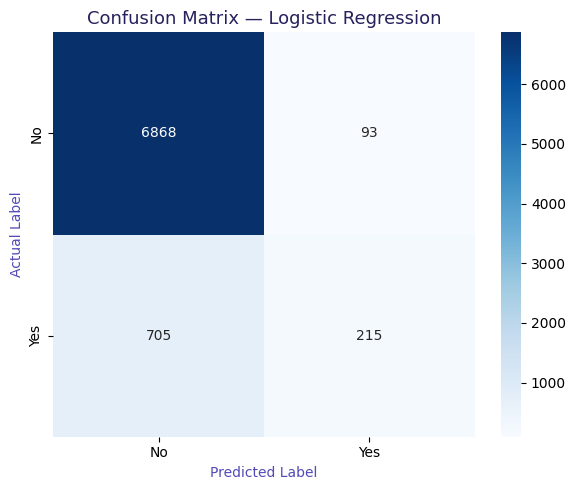

In [24]:
# Confusion Matrix — Logistic Regression
# Shows how many predictions were correct and how many were wrong
plt.figure(figsize=(6, 5))
cm_lr = confusion_matrix(y_test, lr_pred)
sns.heatmap(cm_lr, annot=True, fmt='d', cmap='Blues',
            xticklabels=['No', 'Yes'], yticklabels=['No', 'Yes'])

plt.title('Confusion Matrix — Logistic Regression', color=colors['title'], fontsize=13)
plt.xlabel('Predicted Label', color=colors['subtitle'])
plt.ylabel('Actual Label', color=colors['subtitle'])
plt.tight_layout()
plt.show()

---
### Model 2 — Decision Tree Classifier

A Decision Tree works by asking a series of yes/no questions about the features to reach a prediction. It is easy to visualize and interpret. We limit the tree depth to 5 to avoid overfitting.

In [25]:
dt_model = DecisionTreeClassifier(max_depth=5, random_state=42)
dt_model.fit(X_train, y_train)

dt_pred = dt_model.predict(X_test)
dt_acc  = accuracy_score(y_test, dt_pred)

print(f'Decision Tree Accuracy: {dt_acc * 100:.2f}%')
print()
print('Classification Report:')
print(classification_report(y_test, dt_pred))

Decision Tree Accuracy: 90.08%

Classification Report:
              precision    recall  f1-score   support

           0       0.91      0.98      0.95      6961
           1       0.68      0.29      0.40       920

    accuracy                           0.90      7881
   macro avg       0.79      0.63      0.67      7881
weighted avg       0.88      0.90      0.88      7881



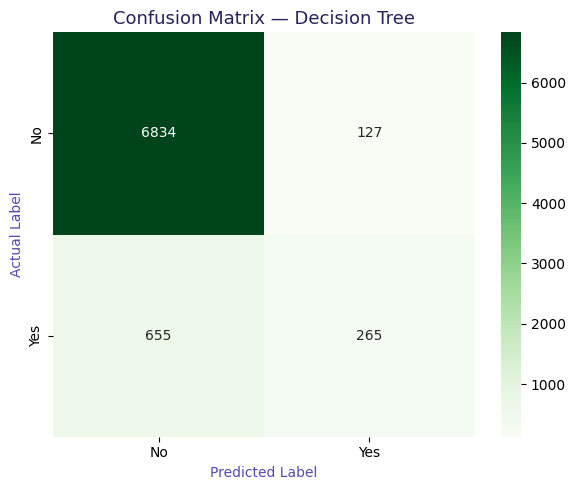

In [26]:
# Confusion Matrix — Decision Tree
plt.figure(figsize=(6, 5))
cm_dt = confusion_matrix(y_test, dt_pred)
sns.heatmap(cm_dt, annot=True, fmt='d', cmap='Greens',
            xticklabels=['No', 'Yes'], yticklabels=['No', 'Yes'])

plt.title('Confusion Matrix — Decision Tree', color=colors['title'], fontsize=13)
plt.xlabel('Predicted Label', color=colors['subtitle'])
plt.ylabel('Actual Label', color=colors['subtitle'])
plt.tight_layout()
plt.show()

---
### Feature Importance

Feature importance tells us which columns had the most influence on the model decision. A higher score means that feature contributed more to making accurate predictions.

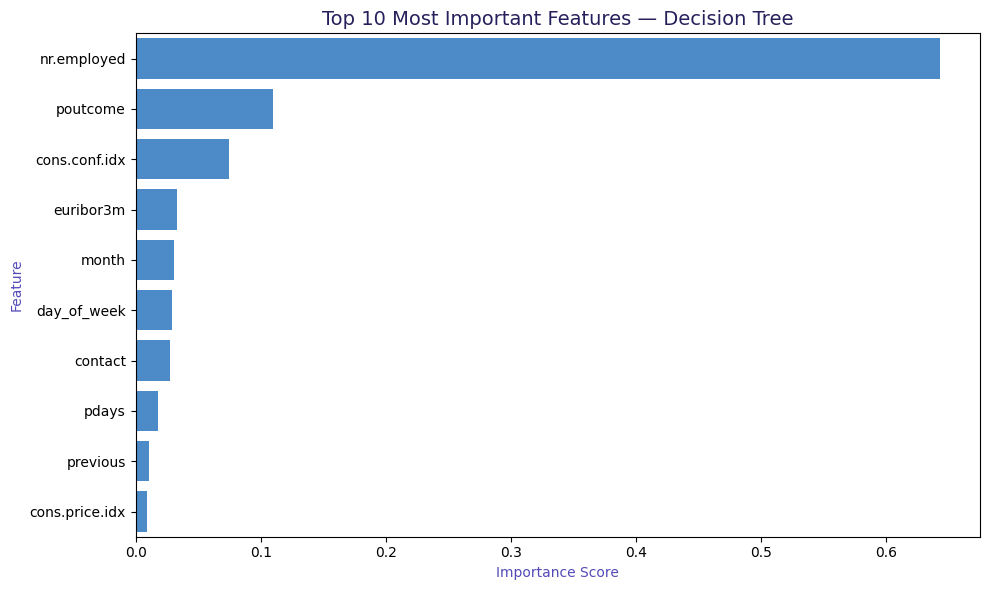

In [27]:
feature_importance = pd.DataFrame({
    'Feature'   : X.columns,
    'Importance': dt_model.feature_importances_
}).sort_values('Importance', ascending=False).head(10)

plt.figure(figsize=(10, 6))
sns.barplot(x='Importance', y='Feature', data=feature_importance,
            color=colors['cellular'])

plt.title('Top 10 Most Important Features — Decision Tree', color=colors['title'], fontsize=14)
plt.xlabel('Importance Score', color=colors['subtitle'])
plt.ylabel('Feature', color=colors['subtitle'])
plt.tight_layout()
plt.show()

---
### Model Comparison

We compare both models side by side to identify which one performed better on the test data.

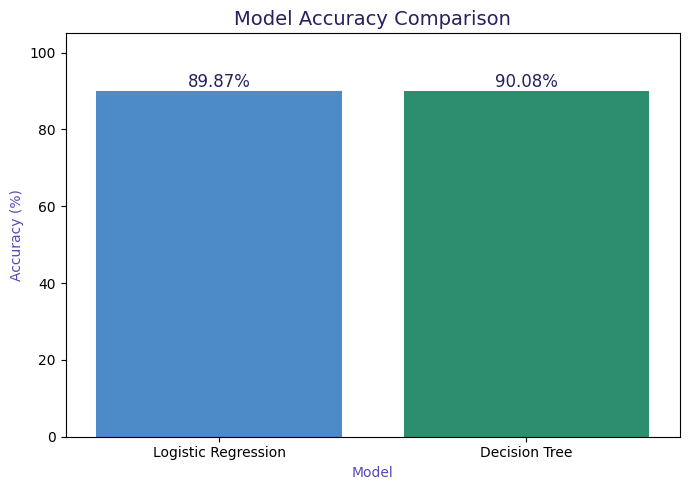

Logistic Regression Accuracy : 89.87%
Decision Tree Accuracy       : 90.08%

Best Performing Model: Decision Tree


In [28]:
comparison = pd.DataFrame({
    'Model'   : ['Logistic Regression', 'Decision Tree'],
    'Accuracy': [lr_acc * 100, dt_acc * 100]
})

plt.figure(figsize=(7, 5))
bars = sns.barplot(x='Model', y='Accuracy', data=comparison,
                   palette=[colors['cellular'], colors['yes']])

for p in bars.patches:
    bars.annotate(f'{p.get_height():.2f}%',
                  (p.get_x() + p.get_width() / 2., p.get_height()),
                  ha='center', va='bottom', fontsize=12, color=colors['title'])

plt.title('Model Accuracy Comparison', color=colors['title'], fontsize=14)
plt.xlabel('Model', color=colors['subtitle'])
plt.ylabel('Accuracy (%)', color=colors['subtitle'])
plt.ylim(0, 105)
plt.tight_layout()
plt.show()

print(f'Logistic Regression Accuracy : {lr_acc * 100:.2f}%')
print(f'Decision Tree Accuracy       : {dt_acc * 100:.2f}%')
best = 'Logistic Regression' if lr_acc > dt_acc else 'Decision Tree'
print(f'\nBest Performing Model: {best}')

---
## Conclusion

In this project we explored and analyzed the Bank Marketing Dataset to predict which customers are likely to accept a personal loan offer.

**Key Findings from Visualization:**
- Customers aged 30 to 40 were contacted most frequently by the bank.
- University educated customers showed a higher loan acceptance rate compared to others.
- Customers contacted via mobile (cellular) accepted the offer more than those on landline.
- When the employment rate was low, more customers accepted the loan offer.
- March, September, and October had the highest loan acceptance rates among all months.
- Customers who had a successful previous campaign outcome were far more likely to accept again.

**Model Results:**
- Logistic Regression and Decision Tree were both trained and evaluated on the same test data.
- Feature importance analysis identified the columns that most influenced loan acceptance.
- The best performing model was selected based on accuracy score on the test set.